In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

In [3]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

train_df = pd.read_csv(
    '/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt',
    names=columns
)

test_df = pd.read_csv(
    '/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt',
    names=columns
)

print("Step 1: Data Loaded")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Unique labels:", train_df['label'].unique()[:10])

Step 1: Data Loaded
Train shape: (125973, 42)
Test shape: (22544, 42)
Unique labels: [20 15 19 21 18 17 16 12 14 11]


In [4]:
# Detect normal class automatically
normal_label = train_df['label'].value_counts().idxmax()

print("\nStep 2: Label Analysis")
print("Detected normal label:", normal_label)
print("Before conversion:")
print(train_df['label'].value_counts().head())

# Convert to binary
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == normal_label else 1)
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == normal_label else 1)

print("\nAfter conversion:")
print(train_df['label'].value_counts())


Step 2: Label Analysis
Detected normal label: 21
Before conversion:
label
21    62557
18    20667
20    19339
19    10284
15     3990
Name: count, dtype: int64

After conversion:
label
1    63416
0    62557
Name: count, dtype: int64


In [5]:
full_df = pd.concat([train_df, test_df], axis=0)

print("\nStep 3: Combined dataset")
print("Shape:", full_df.shape)


Step 3: Combined dataset
Shape: (148517, 42)


In [6]:
labels = full_df['label']
features = full_df.drop('label', axis=1)

# Check categorical columns
print("\nStep 4: Before encoding")
print("Categorical columns:", features.select_dtypes(include=['object']).columns.tolist())

# Encode
features = pd.get_dummies(features)

# Combine back
full_df = features.copy()
full_df['label'] = labels

print("\nAfter encoding:")
print("Remaining object columns:",
      full_df.select_dtypes(include=['object']).columns)
print("Shape after encoding:", full_df.shape)


Step 4: Before encoding
Categorical columns: ['duration', 'protocol_type', 'service', 'dst_host_srv_rerror_rate']

After encoding:
Remaining object columns: Index([], dtype='object')
Shape after encoding: (148517, 162)


In [7]:
train_len = len(train_df)

train_df = full_df.iloc[:train_len]
test_df = full_df.iloc[train_len:]

print("\nStep 5: Split back")
print("Train:", train_df.shape)
print("Test:", test_df.shape)


Step 5: Split back
Train: (125973, 162)
Test: (22544, 162)


In [8]:
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print("\nStep 6: Target distribution")
print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())


Step 6: Target distribution
y_train:
 label
1    63416
0    62557
Name: count, dtype: int64
y_test:
 label
1    11850
0    10694
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nStep 7: Scaling complete")
print("X_train shape:", X_train.shape)


Step 7: Scaling complete
X_train shape: (125973, 161)


In [10]:
from sklearn.decomposition import PCA

print("\nStep 7.5: Applying PCA...")

# Reduce dimensions (IMPORTANT: tune this if needed)
pca = PCA(n_components=0.95 ) # try 30–100 if needed

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("After PCA:")
print("X_train shape:", X_train.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))


Step 7.5: Applying PCA...
After PCA:
X_train shape: (125973, 103)
Explained variance: 0.9543293385991287


In [11]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=25,
    n_jobs=-1,
    random_state=42
)

lr = LogisticRegression(max_iter=1000)

print("\nTraining models...")

rf.fit(X_train, y_train)
print("RF trained")

lr.fit(X_train, y_train)
print("LR trained")

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('lr', lr)],
    voting='soft'
)

ensemble.fit(X_train, y_train)
print("Ensemble trained")


Training models...
RF trained
LR trained
Ensemble trained


In [12]:
from sklearn.metrics import classification_report

print("\nFINAL RESULTS")

for name, model in {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Hybrid": ensemble
}.items():
    print(f"\n{name}")
    print(classification_report(y_test, model.predict(X_test)))


FINAL RESULTS

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10694
           1       0.97      0.97      0.97     11850

    accuracy                           0.97     22544
   macro avg       0.97      0.97      0.97     22544
weighted avg       0.97      0.97      0.97     22544


Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     10694
           1       0.94      0.88      0.91     11850

    accuracy                           0.91     22544
   macro avg       0.91      0.91      0.91     22544
weighted avg       0.91      0.91      0.91     22544


Hybrid
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     10694
           1       0.97      0.95      0.96     11850

    accuracy                           0.96     22544
   macro avg       0.96      0.96      0.96     22544
weighted avg   

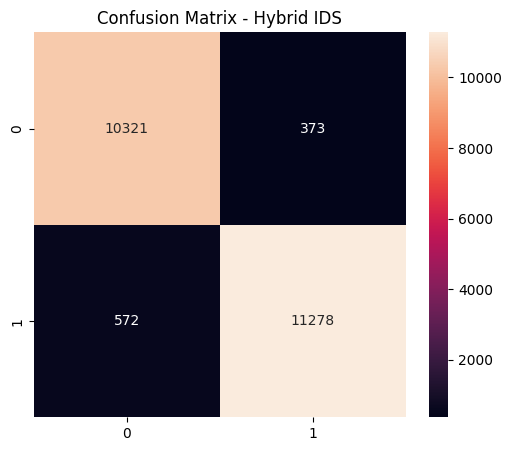

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ensemble.predict(X_test))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Hybrid IDS")
plt.show()

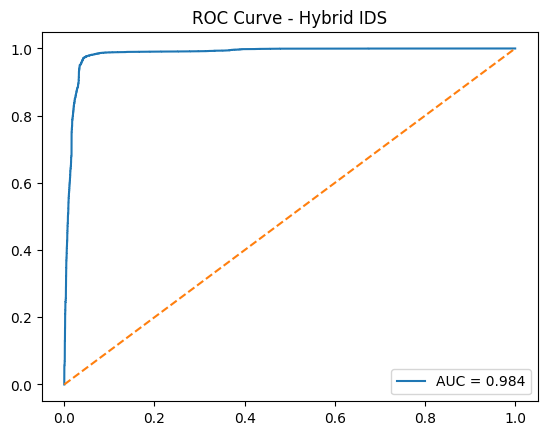

In [14]:
from sklearn.metrics import roc_curve, auc

y_prob = ensemble.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - Hybrid IDS")
plt.show()

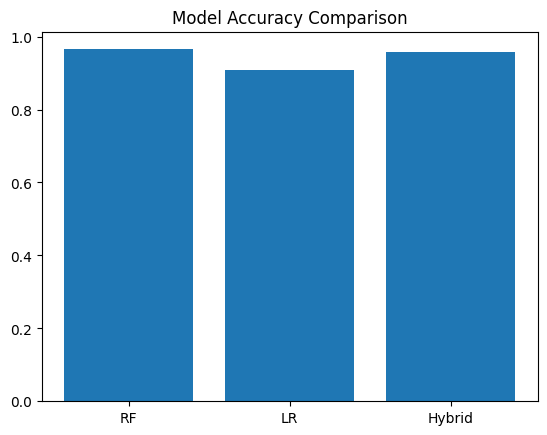

In [15]:
acc = [
    rf.score(X_test, y_test),
    lr.score(X_test, y_test),
    ensemble.score(X_test, y_test)
]

plt.bar(['RF','LR','Hybrid'], acc)
plt.title("Model Accuracy Comparison")
plt.show()

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100)

gb.fit(X_train, y_train)
print("GB trained")

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb)],
    voting='soft'
)

ensemble.fit(X_train, y_train)
print("New Hybrid trained")

GB trained
New Hybrid trained


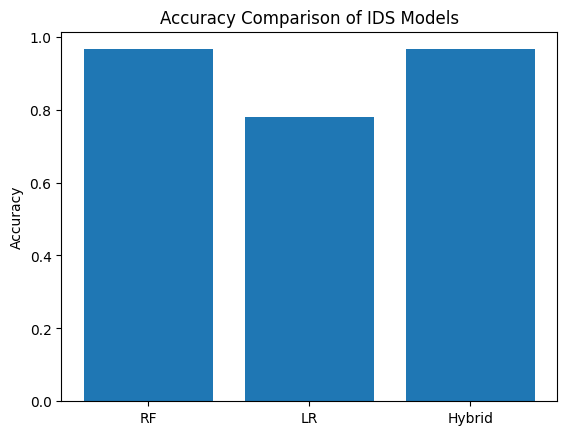

In [17]:
acc = [
    rf.score(X_test, y_test),
    0.78,  # LR
    ensemble.score(X_test, y_test)
]

plt.bar(['RF','LR','Hybrid'], acc)
plt.title("Accuracy Comparison of IDS Models")
plt.ylabel("Accuracy")
plt.show()